# Elastic Disks Pixel-Space Stochastic Interpolant

Conditional drift learning with Euler–Maruyama sampling (pixels).


In [1]:
from pathlib import Path
import subprocess
import sys

GITHUB_REPO_URL = "https://github.com/jordanshivers/generative-video-forecasting.git"
REPO_DIRNAME = "generative-video-forecasting"
INSTALL_REQUIREMENTS = True
RETRAIN = False


def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src" / "video_forecasting").exists():
            return candidate
    if Path("/content").exists():
        repo_root = Path("/content") / REPO_DIRNAME
        if not repo_root.exists():
            subprocess.run(["git", "clone", GITHUB_REPO_URL, str(repo_root)], check=True)
        return repo_root
    raise RuntimeError("Could not find the generative-video-forecasting repository root.")


REPO_ROOT = find_repo_root()
if INSTALL_REQUIREMENTS and Path("/content").exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_ROOT / "requirements.txt")], check=True)

sys.path.insert(0, str(REPO_ROOT / "src"))
print(f"Repo root: {REPO_ROOT}")


Repo root: /content/generative-video-forecasting


In [2]:
import imageio
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from video_forecasting.models.stochastic_interpolants import (
    StochasticInterpolantUtils,
    build_stochastic_interpolant_unet,
)
from video_forecasting.models.diffusion import DiffusionScheduler
from video_forecasting.runtime import get_data_dir, get_device, get_output_dir, set_seed
from video_forecasting.presets import batch_size_for_device, get_preset
from video_forecasting.training import ContextFramePredictionDataset, count_parameters
from video_forecasting.visualization import display_video, plot_training_curves, set_output_dir

set_seed(42)
device = get_device(prefer_mps=True)
DATA_DIR = get_data_dir(REPO_ROOT)
OUTPUT_DIR = get_output_dir("train_elastic_disks_pixel_stochastic_interpolant", REPO_ROOT)
set_output_dir(OUTPUT_DIR)
print(f"Device: {device}")
print(f"Output dir: {OUTPUT_DIR}")
from video_forecasting.training import evaluate_pixel_stochastic_interpolant, train_pixel_stochastic_interpolant_epoch
from video_forecasting.visualization import generate_pixel_stochastic_interpolant_rollout_movie, visualize_pixel_stochastic_interpolant_predictions


Device: cuda
Output dir: /content/generative-video-forecasting/outputs/train_elastic_disks_pixel_stochastic_interpolant


## Dataset


In [3]:
from video_forecasting.datasets.elastic_disks import ElasticDisksDataset

dataset_cfg = get_preset("elastic_disks")
method_cfg = get_preset("pixel_stochastic_interpolant")
context_frames = method_cfg["context_frames"]
num_sequences = dataset_cfg["num_sequences"]
max_sequences = dataset_cfg["max_sequences"]
sequence_length = dataset_cfg["sequence_length"]
frame_separation = dataset_cfg["frame_separation"]
batch_size = batch_size_for_device(device, method_cfg["batch_size"])

train_dataset = ElasticDisksDataset(
    root=str(DATA_DIR),
    train=True,
    num_sequences=num_sequences,
    sequence_length=sequence_length,
    image_size=dataset_cfg["image_size"],
    num_particles=dataset_cfg["num_particles"],
    boundary="reflecting",
    render_mode=dataset_cfg["render_mode"],
    normalize=True,
    frame_separation=frame_separation,
    seed=42,
    max_sequences=max_sequences,
)
test_dataset = ElasticDisksDataset(
    root=str(DATA_DIR),
    train=False,
    num_sequences=num_sequences,
    sequence_length=sequence_length,
    image_size=dataset_cfg["image_size"],
    num_particles=dataset_cfg["num_particles"],
    boundary="reflecting",
    render_mode=dataset_cfg["render_mode"],
    normalize=True,
    frame_separation=frame_separation,
    seed=42,
    max_sequences=max_sequences,
)

train_dataset = ContextFramePredictionDataset(train_dataset, context_frames=context_frames)
test_dataset = ContextFramePredictionDataset(test_dataset, context_frames=context_frames)

pin_memory = device.type == "cuda"
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)
print(f"Train samples: {len(train_dataset)}; test samples: {len(test_dataset)}")



Dataset initialized:
  Dataset: elastic_disks
  Split: train
  Total sequences: 2000
  Boundary: reflecting
  Render mode: hard
  Particles: 6
  Frame separation: 1
  Total pairs: 62000
  Image size: 64x64
  Channels: 1 (grayscale)

Dataset initialized:
  Dataset: elastic_disks
  Split: test
  Total sequences: 500
  Boundary: reflecting
  Render mode: hard
  Particles: 6
  Frame separation: 1
  Total pairs: 15500
  Image size: 64x64
  Channels: 1 (grayscale)
Train samples: 44000; test samples: 11000


## Model


In [4]:
si_utils = StochasticInterpolantUtils(
    sigma_coef=method_cfg["sigma_coef"],
    beta_fn=method_cfg["beta_fn"],
)
model = build_stochastic_interpolant_unet(
    latent_channels=1,
    condition_channels=context_frames,
    out_channels=1,
    time_emb_dim=method_cfg["time_emb_dim"],
    base_channels=method_cfg["base_channels"],
    channel_multipliers=(1, 2, 2),
    num_res_blocks=1,
    groups=8,
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=method_cfg["learning_rate"], weight_decay=1e-4)
checkpoint_path = OUTPUT_DIR / "pixel_stochastic_interpolant_elastic_disks_model.pt"
print(f"Parameters: {count_parameters(model):,}")


Parameters: 919,105


## Train


In [5]:
num_epochs = method_cfg["num_epochs"]
train_losses = []
val_losses = []

if checkpoint_path.exists() and not RETRAIN:
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Loaded checkpoint: {checkpoint_path}")
else:
    for epoch in range(num_epochs):
        train_loss = train_pixel_stochastic_interpolant_epoch(model, train_loader, si_utils, optimizer, device)
        val_loss = evaluate_pixel_stochastic_interpolant(model, test_loader, si_utils, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch + 1}/{num_epochs}: train={train_loss:.5f}, val={val_loss:.5f}")
    torch.save(model.state_dict(), checkpoint_path)
    plot_training_curves(
        train_losses,
        val_losses,
        output_path=OUTPUT_DIR / "pixel_stochastic_interpolant_training_curves.png",
        title="Pixel-Space Stochastic Interpolant Training Curves",
    )
    print(f"Saved checkpoint: {checkpoint_path}")


Evaluating Pixel Stochastic Interpolant: 100%|██████████| 172/172 [00:03<00:00, 48.42it/s]


Epoch 1/50: train=0.36014, val=0.13890


Evaluating Pixel Stochastic Interpolant: 100%|██████████| 172/172 [00:03<00:00, 47.92it/s]


Epoch 2/50: train=0.11148, val=0.08990


Evaluating Pixel Stochastic Interpolant: 100%|██████████| 172/172 [00:03<00:00, 50.84it/s]


...

Epoch 48/50: train=0.01093, val=0.01076


Evaluating Pixel Stochastic Interpolant: 100%|██████████| 172/172 [00:03<00:00, 50.93it/s]


Epoch 49/50: train=0.01076, val=0.01062


Evaluating Pixel Stochastic Interpolant: 100%|██████████| 172/172 [00:03<00:00, 50.64it/s]


Epoch 50/50: train=0.01089, val=0.01127
Saved checkpoint: /content/generative-video-forecasting/outputs/train_elastic_disks_pixel_stochastic_interpolant/pixel_stochastic_interpolant_elastic_disks_model.pt


## Evaluate

Create prediction figures, generate an autoregressive rollout movie, and display it inline.


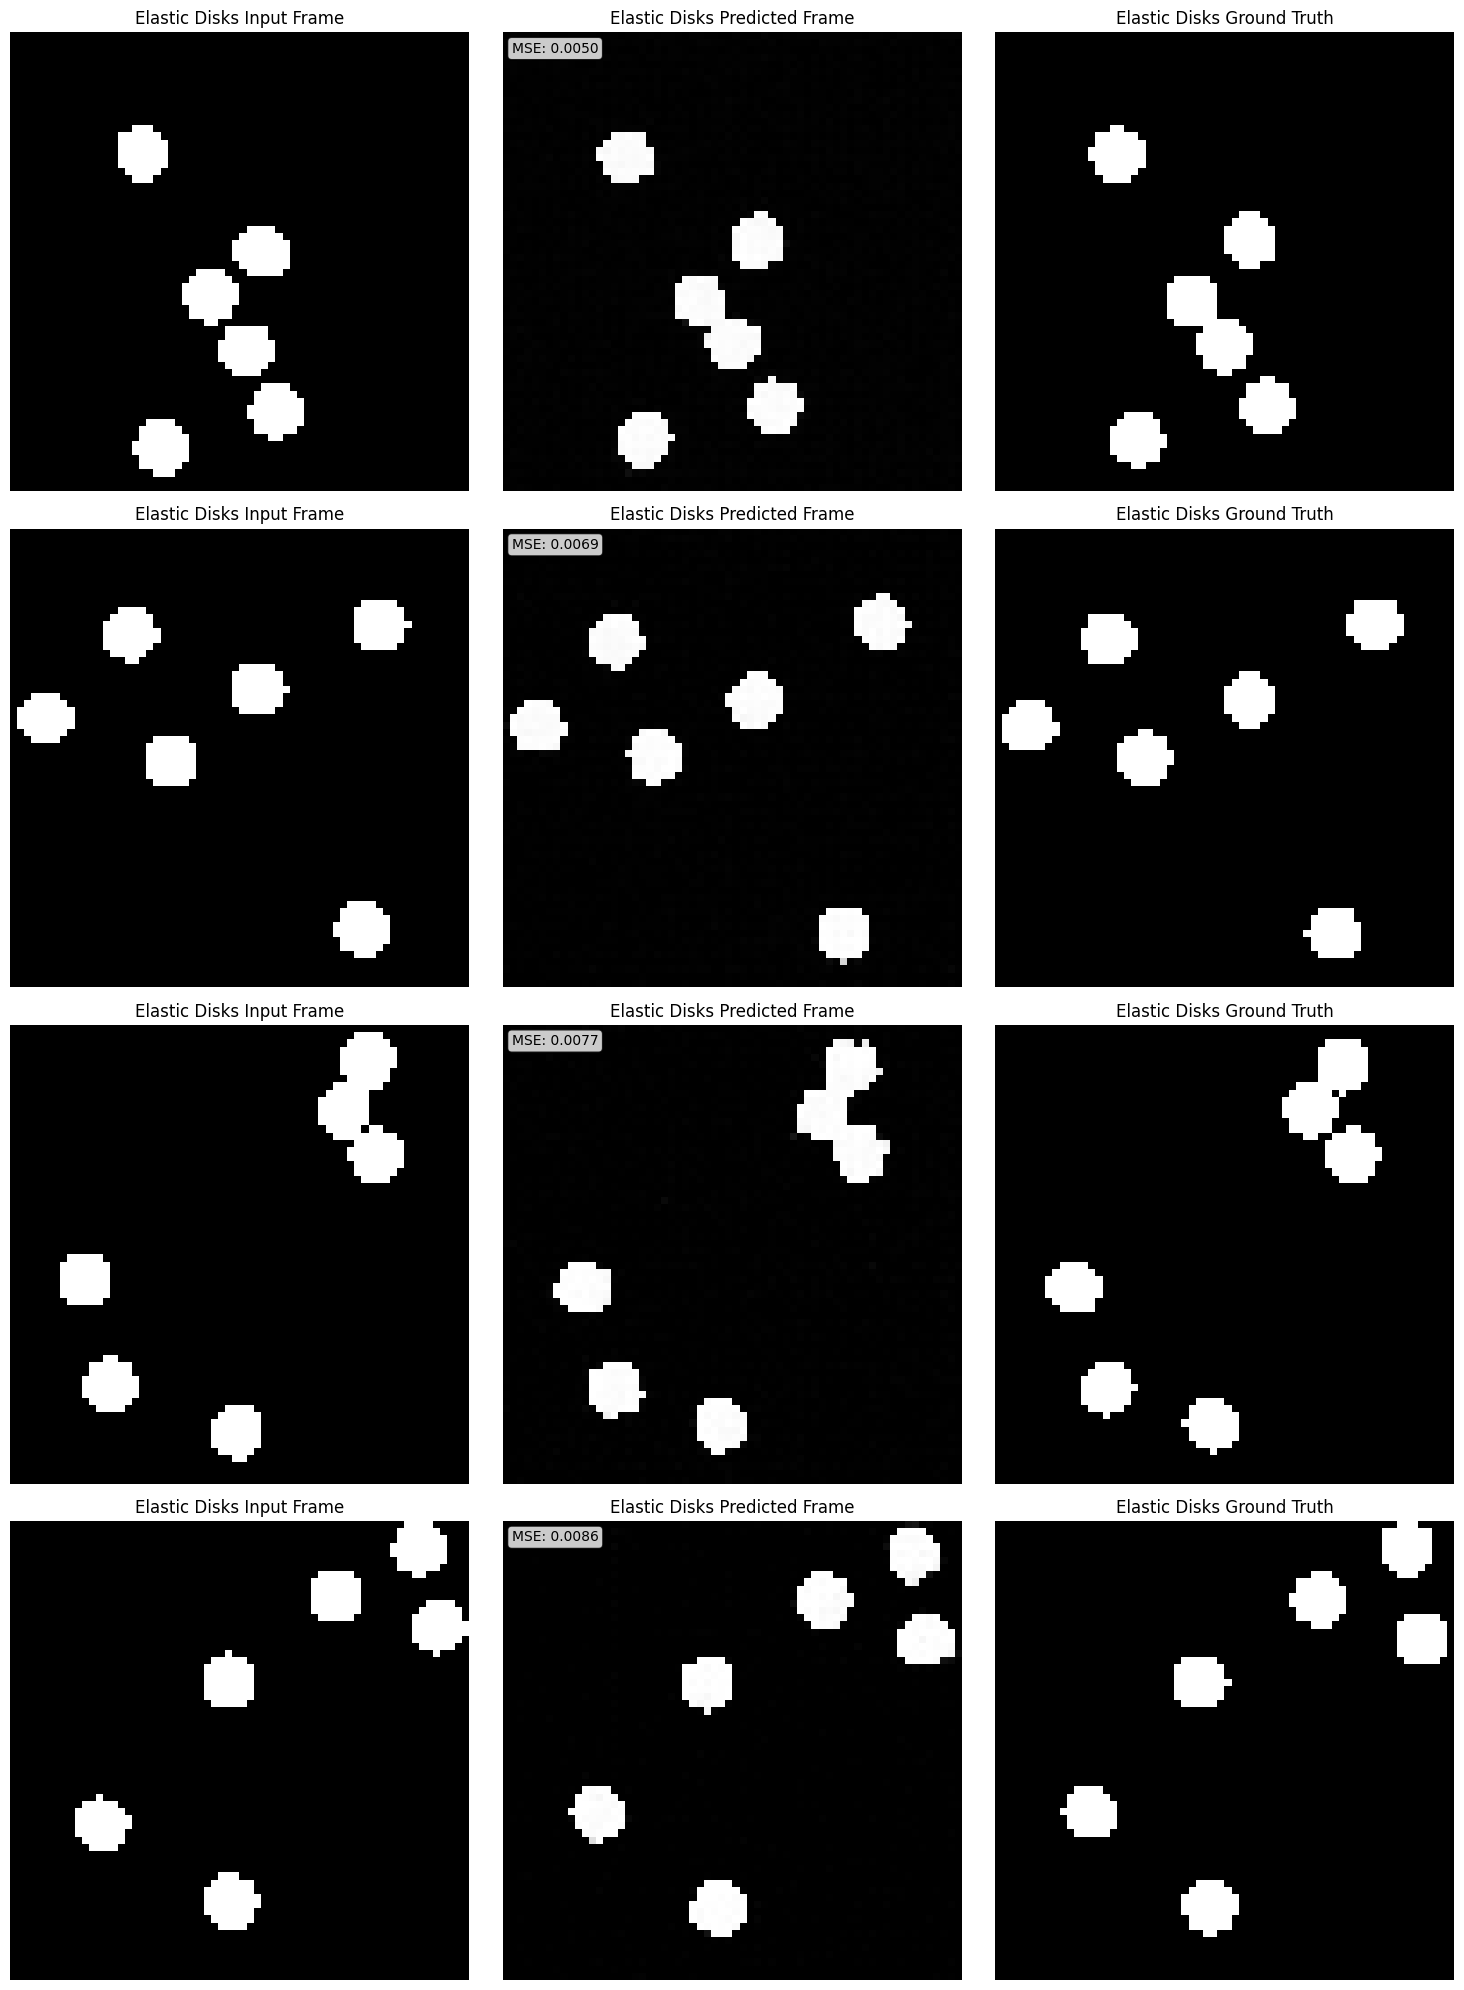

Generating predictions: 100%|██████████| 12/12 [00:04<00:00,  2.74it/s]


Rollout movie saved to: /content/generative-video-forecasting/outputs/train_elastic_disks_pixel_stochastic_interpolant/output_mp4s/elastic_disks_sequence_0_pixel_stochastic_interpolant_rollout.mp4


In [6]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

visualize_pixel_stochastic_interpolant_predictions(
    model,
    test_dataset,
    si_utils,
    num_samples=4,
    device=device,
    title_prefix="Elastic Disks ",
    num_inference_steps=method_cfg["num_inference_steps"],
)

test_sequence_idx = 0
test_sequence = test_dataset.sequences[test_sequence_idx]
rollout_path = generate_pixel_stochastic_interpolant_rollout_movie(
    model,
    test_dataset,
    si_utils,
    sequence=test_sequence,
    dataset_type="elastic_disks",
    frame_separation=frame_separation,
    context_frames=context_frames,
    start_frame=0,
    num_predictions=12,
    device=device,
    fps=10,
    output_dir=str(OUTPUT_DIR / "output_mp4s"),
    num_inference_steps=method_cfg["num_inference_steps"],
)
print(f"Rollout movie saved to: {rollout_path}")
display_video(rollout_path)
